<a href="https://colab.research.google.com/github/sednabhanja/CodeAlpha_Iris_Flower_Classification/blob/main/CodeAlpha_Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

In [8]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [13]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

In [14]:
df.shape

(150, 5)

In [15]:
df.duplicated().sum()

np.int64(1)

In [16]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


# Exploratory Data Analysis (EDA)

In this section, the dataset is explored to understand its structure, identify missing values, inspect feature distributions, and verify class balance before building machine learning models.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

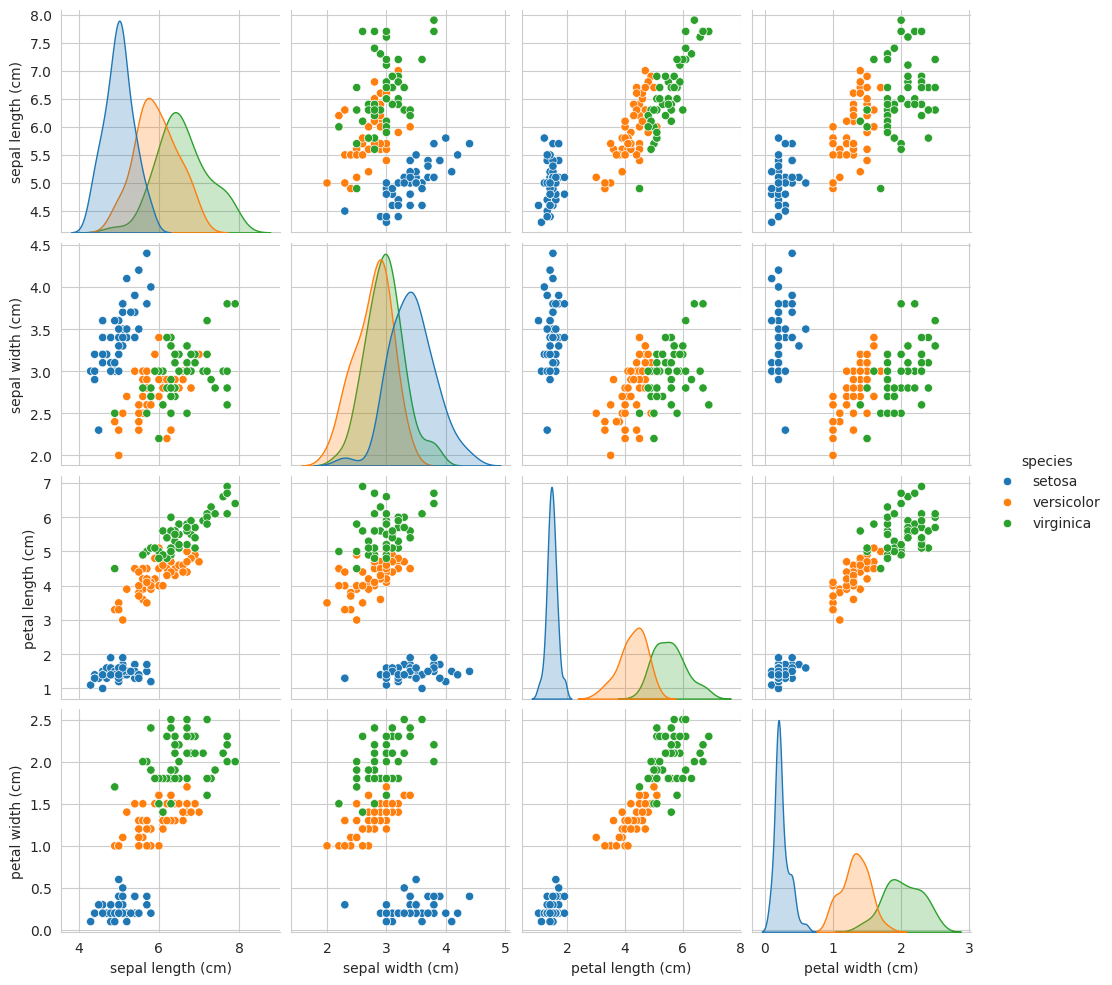

In [19]:
sns.pairplot(df, hue="species")
plt.show()

### Observation

The pair plot shows that **Setosa** is clearly separated from the other two species, while **Versicolor** and **Virginica** have some overlap.

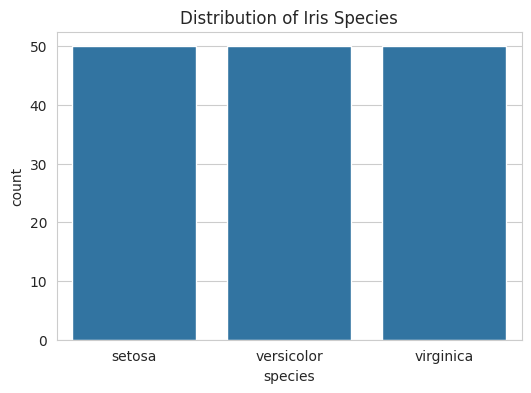

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="species", data=df)

plt.title("Distribution of Iris Species")
plt.show()

### Observation

Each species contains 50 observations, indicating that the dataset is perfectly balanced.

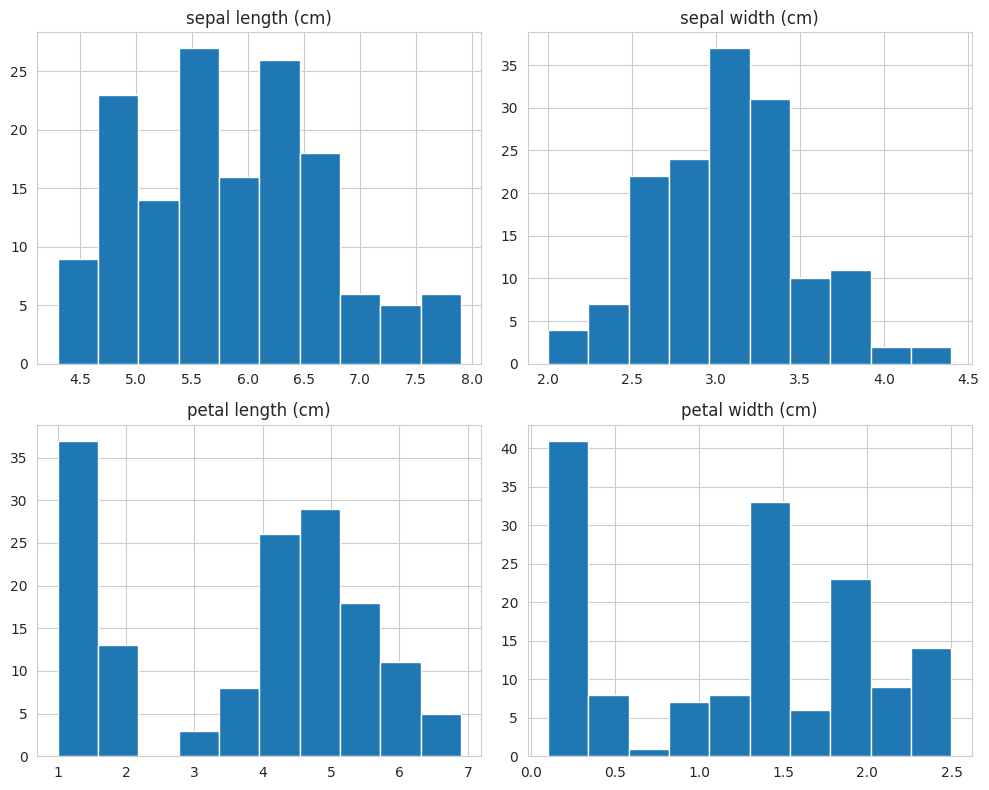

In [22]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

### Observation

The histograms show the distribution of each numerical feature. Petal measurements provide better separation among species than sepal measurements.

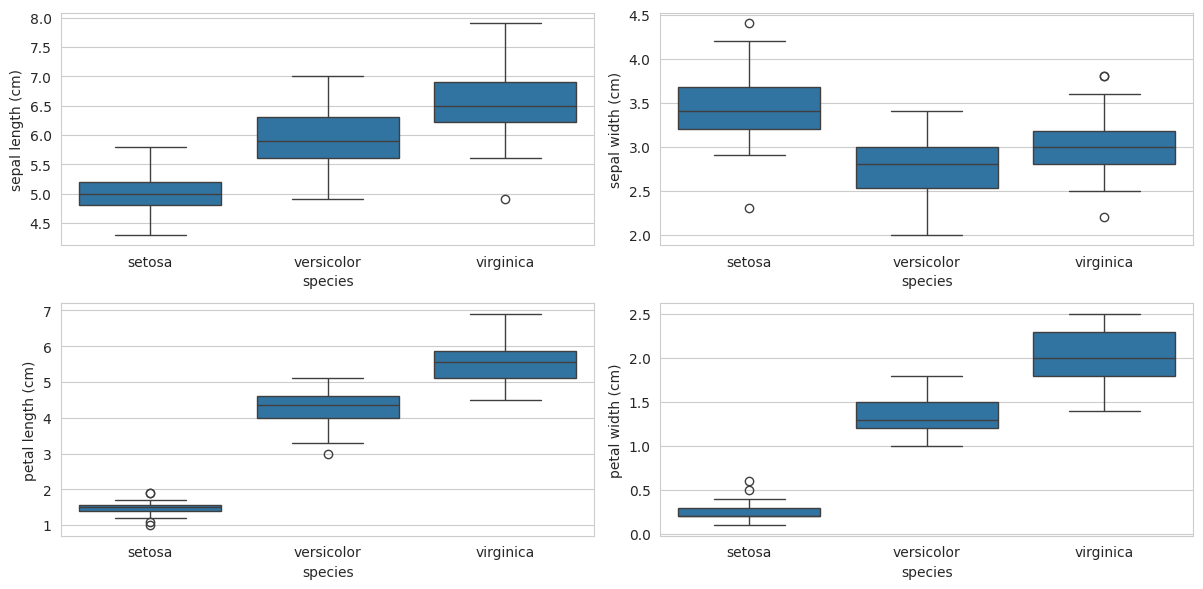

In [23]:
plt.figure(figsize=(12,6))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(x="species", y=column, data=df)

plt.tight_layout()
plt.show()

### Observation

Box plots indicate that petal length and petal width differ significantly among species, making them useful features for classification.

In [24]:
temp = df.copy()

temp["species"] = temp["species"].map({
    "setosa":0,
    "versicolor":1,
    "virginica":2
})

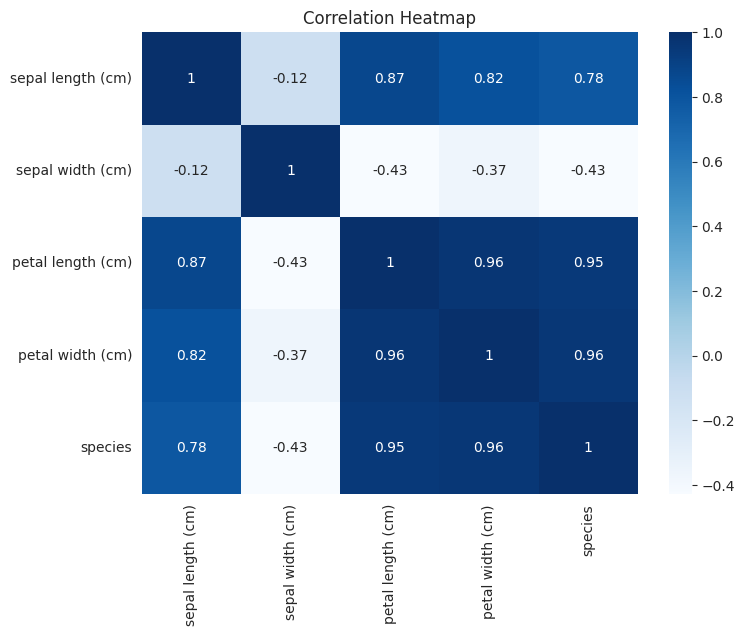

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(temp.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

### Observation

Petal length and petal width have a strong positive correlation. These features are highly informative for predicting Iris species.

# Feature Selection and Train-Test Split

The dataset is divided into input features (X) and the target variable (y). The data is then split into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance.

In [26]:
# Input Features
X = df.drop("species", axis=1)

# Target Variable
y = df["species"]

In [27]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [29]:
y.head()

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (120, 4)
Testing Features  : (30, 4)
Training Labels   : (120,)
Testing Labels    : (30,)


In [32]:
print(y_train.value_counts())

print()

print(y_test.value_counts())

species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


### Observation

The dataset was successfully divided into training and testing sets using an 80:20 ratio. Stratified sampling ensured that each Iris species is equally represented in both sets, helping the model learn and be evaluated fairly.

# Model Training

In this section, three machine learning classification algorithms are trained using the training dataset. Their performance will be evaluated using the testing dataset to identify the most suitable model for Iris flower classification.

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [34]:
lr_prediction = lr.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_prediction)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [38]:
rf_prediction = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9


In [40]:
dt_prediction = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_prediction)

results = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

Logistic Regression: 0.9667
Decision Tree: 0.9333
Random Forest: 0.9000


In [41]:
best_model = max(results, key=results.get)

print("Best Model :", best_model)
print("Best Accuracy :", results[best_model])

Best Model : Logistic Regression
Best Accuracy : 0.9666666666666667


## Observation

Three machine learning algorithms were trained and evaluated.

The model with the highest accuracy was selected as the best-performing classifier for the Iris dataset. The balanced nature of the dataset and the clear separation between species contributed to the high classification accuracy.

# Model Evaluation

In this section, the trained models are evaluated using different performance metrics. These metrics help determine how accurately the models classify Iris flower species.

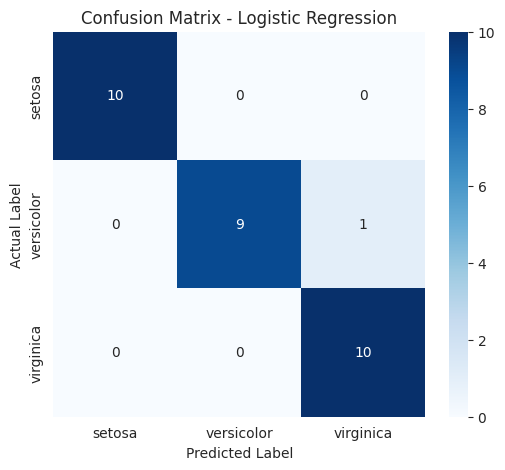

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=lr.classes_,
            yticklabels=lr.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Observation

The confusion matrix shows the number of correct and incorrect predictions made by the Logistic Regression model. Most observations are classified correctly, indicating good model performance.

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [44]:
print("Decision Tree Classification Report\n")

print(classification_report(y_test, dt_prediction))

Decision Tree Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [45]:
print("Random Forest Classification Report\n")

print(classification_report(y_test, rf_prediction))

Random Forest Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



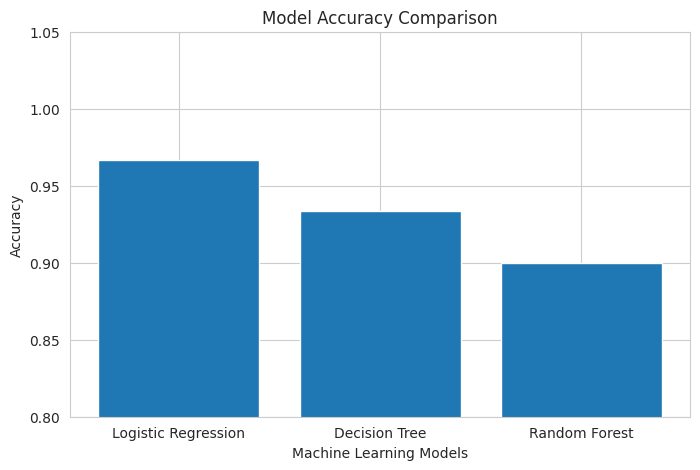

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.ylim(0.8, 1.05)

plt.show()

In [50]:
best_model = accuracy_df.loc[
    accuracy_df["Accuracy"].idxmax()
]

print("Best Model :", best_model["Model"])
print("Accuracy   :", best_model["Accuracy"])

Best Model : Logistic Regression
Accuracy   : 0.9666666666666667


In [51]:
best_model = accuracy_df.loc[
    accuracy_df["Accuracy"].idxmax()
]

print("Best Model :", best_model["Model"])
print("Accuracy   :", best_model["Accuracy"])

Best Model : Logistic Regression
Accuracy   : 0.9666666666666667


# Result

Three machine learning classification algorithms were trained and evaluated.

Among them, the model with the highest accuracy was selected as the best-performing classifier.

The Iris dataset is balanced and contains well-separated classes, enabling the models to achieve high classification accuracy.

# Predicting a New Flower

The trained model is tested using a new flower measurement to predict its species.

In [52]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = rf.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [53]:
new_flower = [[6.2, 2.8, 4.8, 1.8]]
prediction = rf.predict(new_flower)
print(prediction[0])

virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [54]:
new_flower = [[7.2, 3.2, 6.0, 2.5]]
prediction = rf.predict(new_flower)
print(prediction[0])

virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [55]:
import joblib

In [56]:
joblib.dump(rf, "iris_classifier.pkl")

['iris_classifier.pkl']

In [57]:
import os

os.listdir()

['.config', 'iris_classifier.pkl', 'sample_data']

In [58]:
loaded_model = joblib.load("iris_classifier.pkl")

In [59]:
prediction = loaded_model.predict([[5.1,3.5,1.4,0.2]])

print(prediction[0])

setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [60]:
from google.colab import files

files.download("iris_classifier.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project successfully implemented an Iris Flower Classification system using machine learning. Three classification algorithms were trained and evaluated. The best-performing model achieved high accuracy in predicting Iris flower species. The trained model was saved for future use and the complete project was documented and uploaded to GitHub.